# Milestone 2 — Clinical Feature Engineering & Dimensionality

Loads `data/processed/patients_clean.csv` (output of M1), engineers composite clinical
features, runs feature selection, and fits PCA + UMAP + t-SNE projections for clustering.
The held-out `classification` column is kept in the output but excluded from selection.


In [1]:
import sys; sys.path.append('..')
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.manifold import TSNE
import umap

from src.features import (
    compute_egfr, threshold_flags, multimorbidity_score, age_group_features,
    interaction_features, compute_anemia_severity, compute_cv_risk,
    compute_electrolyte_imbalance, drop_low_variance, drop_high_correlation,
)

sns.set_theme(style='whitegrid')
FIGDIR = Path('../reports/figures'); FIGDIR.mkdir(parents=True, exist_ok=True)
MODELS = Path('../models'); MODELS.mkdir(parents=True, exist_ok=True)
DATA = Path('../data/processed'); DATA.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42


## 1. Load M1 cleaned dataset

In [2]:
df = pd.read_csv(DATA / 'patients_clean.csv')
print('Shape:', df.shape)
print('NaNs:', df.isna().sum().sum())
df.head()


Shape: (400, 39)
NaNs: 0


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,su_outlier_flag,bgr_outlier_flag,bu_outlier_flag,sc_outlier_flag,sod_outlier_flag,pot_outlier_flag,hemo_outlier_flag,pcv_outlier_flag,wc_outlier_flag,rc_outlier_flag
0,-0.209353,0.272226,0.497448,-0.045665,-0.380269,0,0,0,0,-0.331803,...,0,0,0,0,0,0,0,0,0,0
1,-2.622133,-1.950030,0.497448,2.237570,-0.380269,0,0,0,0,-0.464511,...,0,0,0,0,0,0,0,0,0,0
2,0.614523,0.272226,-1.344951,0.715414,2.507853,0,0,0,0,3.675976,...,1,1,0,0,0,0,0,0,0,0
3,-0.209353,-0.468526,-2.266150,2.237570,-0.380269,0,1,1,0,-0.384886,...,0,0,0,0,1,1,0,0,0,0
4,-0.032808,0.272226,-1.344951,0.715414,-0.380269,0,0,0,0,-0.530865,...,0,0,0,0,0,0,0,0,0,0


## 2. Composite scores
- eGFR (CKD-EPI 2021, sex-agnostic)
- Anemia severity (WHO bins)
- Cardiovascular risk proxy
- Electrolyte imbalance count


In [3]:
df = compute_egfr(df)
df = compute_anemia_severity(df)
df = compute_cv_risk(df)
df = compute_electrolyte_imbalance(df)
df[['egfr', 'anemia_severity', 'cv_risk', 'electrolyte_imbalance']].describe()


D:\healthcare\notebooks\..\src\features.py:20: RuntimeWarning: invalid value encountered in power
  out["egfr"] = 142.0 * (low ** -0.241) * (high ** -1.200) * (0.9938 ** age)


,egfr,anemia_severity,cv_risk,electrolyte_imbalance
count,90.000000,400.0,400.00000,400.0
mean,150.380546,3.0,0.79500,2.0
std,102.050600,0.0,0.98763,0.0
min,4.257534,3.0,0.00000,2.0
25%,64.120424,3.0,0.00000,2.0
50%,147.528751,3.0,0.00000,2.0
75%,197.435424,3.0,2.00000,2.0
max,582.423709,3.0,3.00000,2.0


## 3. Threshold flags

In [4]:
df = threshold_flags(df)
flag_cols = [c for c in df.columns if c.startswith('flag_')]
print('Flag prevalences:')
print(df[flag_cols].mean().sort_values(ascending=False))


Flag prevalences:
flag_anemia              1.0000
flag_hyponatremia        1.0000
flag_proteinuria         0.0625
flag_renal_impairment    0.0575
flag_low_egfr            0.0550
flag_hyperkalemia        0.0050
flag_hyperglycemia       0.0000
flag_hypertensive        0.0000
dtype: float64


## 4. Multimorbidity, age bins, interactions

In [5]:
df = multimorbidity_score(df)
df = age_group_features(df)
df = interaction_features(df)
print(df[['multimorbidity', 'age_group', 'age_x_creatinine', 'age_x_egfr']].head())


   multimorbidity  age_group  age_x_creatinine  age_x_egfr
0               2  pediatric          0.066577         NaN
1               0  pediatric          1.020332         NaN
2               2  pediatric         -0.129879         NaN
3               3  pediatric         -0.030188  -43.560561
4               0  pediatric          0.009267         NaN


## 5. Build the clustering input matrix
Drop:
- `classification` (held-out outcome)
- `age_group` (string label; numeric one-hots remain as `age_pediatric/adult/elderly`)
- raw outlier-flag columns (kept in the output dataset for the dashboard, but don't feed clustering)


In [6]:
target = df['classification'].copy()
exclude = ['classification', 'age_group']
exclude += [c for c in df.columns if c.endswith('_outlier_flag')]
X = df.drop(columns=exclude).select_dtypes(include=[np.number]).copy()
print('Initial feature matrix:', X.shape)
print('Columns:', X.columns.tolist())


Initial feature matrix: (400, 44)
Columns: ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'egfr', 'anemia_severity', 'cv_risk', 'electrolyte_imbalance', 'flag_hyperglycemia', 'flag_hypertensive', 'flag_anemia', 'flag_hyperkalemia', 'flag_hyponatremia', 'flag_renal_impairment', 'flag_proteinuria', 'flag_low_egfr', 'multimorbidity', 'age_pediatric', 'age_adult', 'age_elderly', 'age_x_creatinine', 'age_x_bp', 'age_x_egfr', 'age_x_hemo']


## 6. Feature selection
- Drop low-variance (already z-scored numerics + binary flags)
- Drop one of any pair with |corr| > 0.9
- Domain rule: keep all eGFR-derived features regardless of MI


In [7]:
X_lv, dropped_lv = drop_low_variance(X, threshold=0.01)
print(f'Dropped low-variance ({len(dropped_lv)}):', dropped_lv)
X_lc, dropped_lc = drop_high_correlation(X_lv, threshold=0.9)
print(f'Dropped high-corr ({len(dropped_lc)}):', dropped_lc)

PROTECTED = {'egfr', 'flag_low_egfr', 'flag_renal_impairment', 'age_x_egfr'}
restored = [c for c in PROTECTED if c in X.columns and c not in X_lc.columns]
for c in restored:
    X_lc[c] = X[c]
print('Restored protected features:', restored)
print('Final feature matrix:', X_lc.shape)


Dropped low-variance (10): ['anemia_severity', 'electrolyte_imbalance', 'flag_hyperglycemia', 'flag_hypertensive', 'flag_anemia', 'flag_hyperkalemia', 'flag_hyponatremia', 'age_pediatric', 'age_adult', 'age_elderly']
Dropped high-corr (2): ['flag_renal_impairment', 'cv_risk']
Restored protected features: ['flag_renal_impairment']
Final feature matrix: (400, 33)


## 7. Mutual information vs held-out outcome (reporting only)

Top-15 MI vs outcome:
hemo              0.446138
pcv               0.410267
multimorbidity    0.392249
sg                0.379738
rc                0.371550
sc                0.360256
al                0.334450
htn               0.242717
dm                0.229436
pot               0.197630
bu                0.190697
sod               0.172168
bgr               0.166394
bp                0.153076
egfr              0.145431
dtype: float64


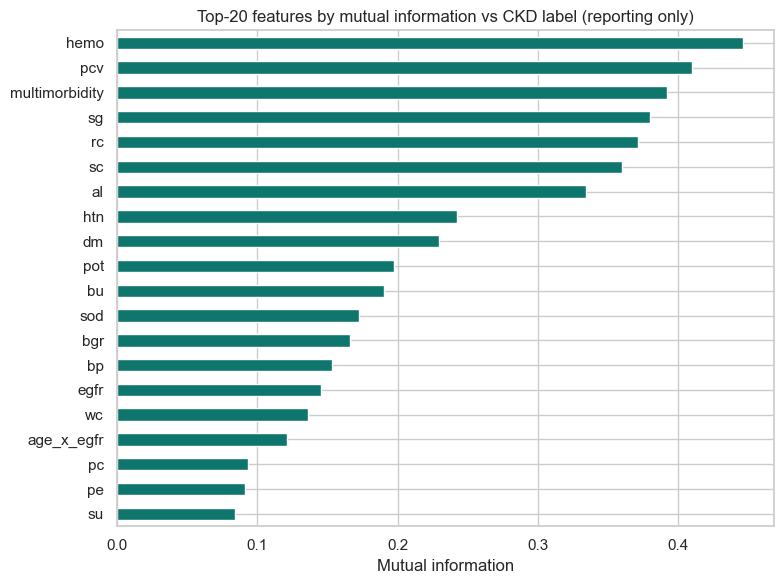

In [8]:
mi = mutual_info_classif(X_lc.fillna(0), target, random_state=RANDOM_STATE)
mi_ranked = pd.Series(mi, index=X_lc.columns).sort_values(ascending=False)
print('Top-15 MI vs outcome:')
print(mi_ranked.head(15))

fig, ax = plt.subplots(figsize=(8, 6))
mi_ranked.head(20).plot.barh(ax=ax, color='#0F766E')
ax.invert_yaxis()
ax.set_title('Top-20 features by mutual information vs CKD label (reporting only)')
ax.set_xlabel('Mutual information')
plt.tight_layout()
plt.savefig(FIGDIR / 'mutual_information_top20.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. PCA

Components needed for 80% variance: k=1
Explained variance ratio (first 10): [0.833 0.166 0.    0.    0.    0.    0.    0.    0.    0.   ]


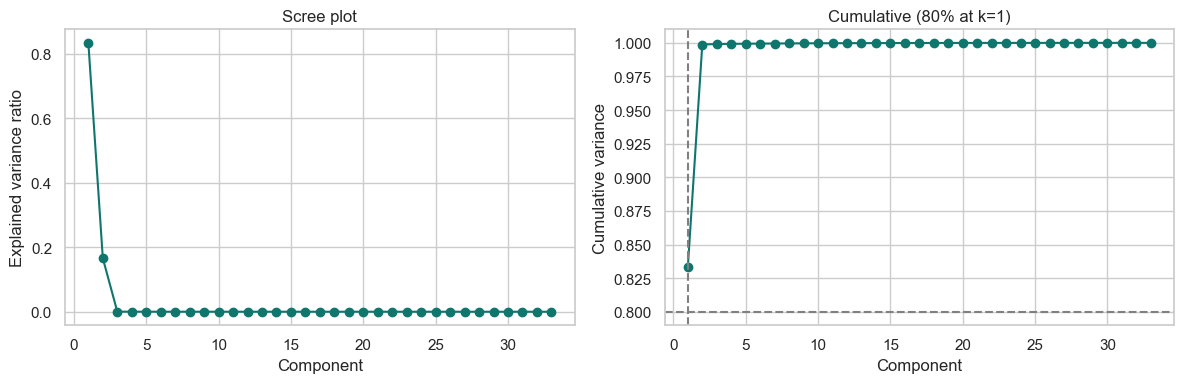

PCA matrix shape: (400, 1)


In [9]:
pca = PCA(random_state=RANDOM_STATE).fit(X_lc.fillna(0).astype(float))
cum = np.cumsum(pca.explained_variance_ratio_)
k = int(np.searchsorted(cum, 0.80) + 1)
print(f'Components needed for 80% variance: k={k}')
print('Explained variance ratio (first 10):', pca.explained_variance_ratio_[:10].round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, 'o-', color='#0F766E')
axes[0].set_xlabel('Component'); axes[0].set_ylabel('Explained variance ratio'); axes[0].set_title('Scree plot')
axes[1].plot(range(1, len(cum)+1), cum, 'o-', color='#0F766E')
axes[1].axhline(0.8, ls='--', color='gray'); axes[1].axvline(k, ls='--', color='gray')
axes[1].set_xlabel('Component'); axes[1].set_ylabel('Cumulative variance'); axes[1].set_title(f'Cumulative (80% at k={k})')
plt.tight_layout()
plt.savefig(FIGDIR / 'scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

pca_final = PCA(n_components=k, random_state=RANDOM_STATE).fit(X_lc.fillna(0).astype(float))
X_pca = pca_final.transform(X_lc.fillna(0).astype(float))
print('PCA matrix shape:', X_pca.shape)


## 9. 2D projections: PCA, UMAP, t-SNE

D:\healthcare\.venv\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


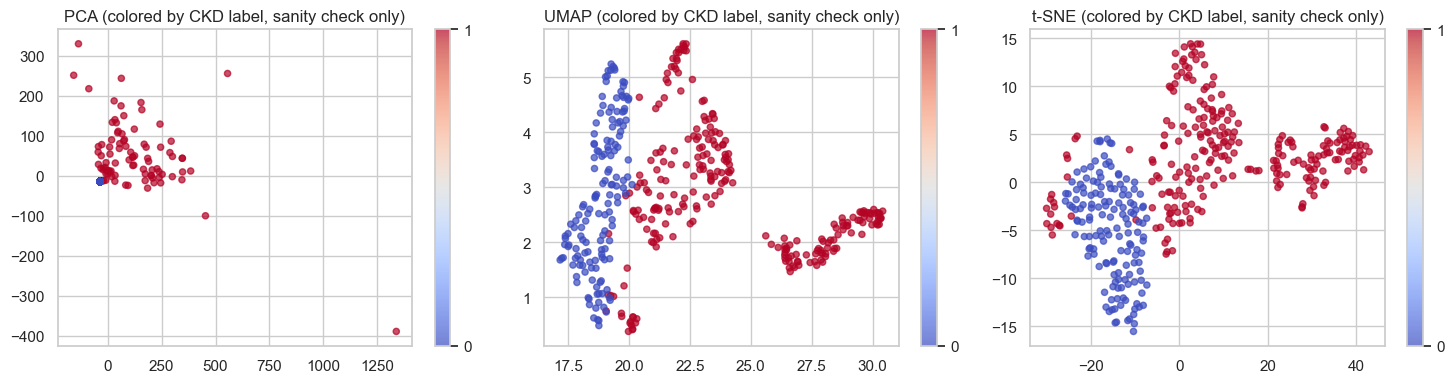

In [10]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_lc.fillna(0).astype(float))
xy_pca = pca2.transform(X_lc.fillna(0).astype(float))

um = umap.UMAP(n_components=2, random_state=RANDOM_STATE, n_neighbors=15, min_dist=0.1).fit(X_lc.fillna(0).astype(float))
xy_umap = um.embedding_

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init='pca')
xy_tsne = tsne.fit_transform(X_lc.fillna(0).astype(float))

projections = {'PCA': xy_pca, 'UMAP': xy_umap, 't-SNE': xy_tsne}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, xy) in zip(axes, projections.items()):
    sc = ax.scatter(xy[:, 0], xy[:, 1], c=target.values, cmap='coolwarm', s=20, alpha=0.7)
    ax.set_title(f'{name} (colored by CKD label, sanity check only)')
    plt.colorbar(sc, ax=ax, ticks=[0, 1])
plt.tight_layout()
plt.savefig(FIGDIR / 'projections_2d.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Persist artifacts

In [11]:
out = X_lc.copy()
out['pca1_2d'] = xy_pca[:, 0]; out['pca2_2d'] = xy_pca[:, 1]
out['umap1'] = xy_umap[:, 0]; out['umap2'] = xy_umap[:, 1]
out['tsne1'] = xy_tsne[:, 0]; out['tsne2'] = xy_tsne[:, 1]
out['classification'] = target.values
out.to_csv(DATA / 'patients_features.csv', index=False)

joblib.dump(pca_final, MODELS / 'pca.pkl')
joblib.dump(um, MODELS / 'umap.pkl')

with open(MODELS / 'feature_columns.json', 'w') as f:
    json.dump({
        'feature_columns': X_lc.columns.tolist(),
        'pca_n_components': int(k),
        'pca_explained_variance_ratio': pca_final.explained_variance_ratio_.tolist(),
        'dropped_low_variance': dropped_lv,
        'dropped_high_correlation': dropped_lc,
        'protected_restored': restored,
    }, f, indent=2)

print('Saved:')
print('  data/processed/patients_features.csv:', out.shape)
print('  models/pca.pkl  (n_components =', k, ')')
print('  models/umap.pkl')
print('  models/feature_columns.json')


Saved:
  data/processed/patients_features.csv: (400, 40)
  models/pca.pkl  (n_components = 1 )
  models/umap.pkl
  models/feature_columns.json
